# From Jupyter Notebook to a Real AI Product

*AI Lab course — Class 1: Web & FastAPI*


## 0. Where we are

This class happens in the **TCS AI Lab**, and the company provides LLMs through an internal **LiteLLM gateway** (a Model-as-a-Service facade with a Swagger interface). 

What to keep in mind from the slides:

```text
Jupyter Notebook (research)  ->  FastAPI Backend (product)  ->  LiteLLM Gateway  ->  LLM
```

- TCS gives employees **models as a service**: you call the gateway, it handles keys, quotas, and providers.
- The gateway and FastAPI both expose **Swagger** docs.
- Our job today is to build a small backend product with FastAPI.

## 1. Why a Jupyter Notebook is not a product

The previous courses lived inside **Jupyter Notebooks**. Notebooks are an excellent **exploratory environment**:

- Great for research, data analysis, and interactive cell-by-cell prompt tuning.
- Fast iteration: write, run, see the result immediately.

But for an **end-user product**, notebooks have critical problems:

### 1. Security & credentials

- **Exposed endpoints**: execution exposes third-party information to the end user.
- **Hardcoded keys**: credentials could be easily extracted.

### 2. Scaling & architecture

- **Single client**: a notebook cannot handle multiple requests at the same time.

### 3. End-user experience

- **Out-of-order execution is impossible**: notebook execution is linear.
- **Poor state resilience**: kernels tend to freeze or crash without failovers.

A real user cannot "run your notebook". A real user calls an **endpoint** and gets a **response**. The bridge between both worlds is a **backend API**, and the framework we use is **FastAPI**.

```text
notebook cell  ->  GET /chat  ->  { "reply": "..." }
```

Let us build that bridge, step by step, following the hands-on from slide 21.


# Hands-on



### Step 0: Git Setup

Only with backup purposes, we will initialize a git repository for our project.

We are not going to introduce much about git. The only two concepts that we are going to use here are:
1. **Commit**: a snapshot of the current state of the project.
2. **Push**: send the commits to a remote repository (GitHub in our case).

#### Git ignore

There are some files that are not convenient to have in a repository. To block git to detect them, create a new file in the root of the folder and call it `.gitignore`

In [ ]:
### DO NOT RUN THIS FILE

### Copy it in the .gitignore file
ai_env
__pycache__
*.pyc
.env

#### Connection Between Visual Studio Code and Github 

How are we going to use git in this course? Via the UI of **Visual Studio Code**. We will not use the command line for git.

1. In the bottom left of this application, there should be an icon with the a profile icon. Click it. If the first option says Github and has something like `<username> (Github)`, hover over it and select **Sign out**. If not, proceed with step 2.
2. Press Ctrl + Shift + P (a pop up in the top center should be shown).
3. Write "Publish to Github"
4. Select the option suggested.
5. A warning pops up, click in "Allow".
6. Go to the browser. Github page should be open and asking for your credentials.
7. Select "Authorize Visual Studio Code"
8. Once you reach the page with the message "You have successfully authorized Visual Studio Code", come back to VS Code.
9. The middle top pop up should be asking for a preference on the repository visibility. Select **Private**.

Now you should be logged if you check at the profile icon on the bottom left. **Do not forget to sign out before leaving the lab.**

You can do an initial commit by going to the **Source Control** tab on the left side of VS Code, writing a commit message, and clicking the check mark. Then click on the three dots and select **Push** to send your changes to GitHub.

> Recommendation: Make a commit every time you finish a step in the hands-on. This way, you can always go back to a previous state if something goes wrong.

## Step 1: Virtual Environment

Before writing any code, we isolate our project dependencies that are different from other projects that we could have. A **virtual environment** keeps the packages for this project separate from the rest of the Python installation of your machine.

Run these commands in a **terminal** (not here in the notebook)

IF NOT CREATED IN PREVIOUS CLASS: Create a project folder and a virtual environment:


In [ ]:
# DO NOT EXECUTE THIS CELL

# Copy the content, paste it in the terminal, and run it.
python -m venv ai_env

### Once created the virtual environment, we proceed to activate it:



In [ ]:
# DO NOT EXCUTE THIS CELL

# Disable AI Lab Scripts Execution Policy (Run it in the terminal only if you are in the AI Lab)

Set-ExecutionPolicy -Scope Process -ExecutionPolicy RemoteSigned   

# Environment activation for Windows (Run it in the terminal):

.\ai_env\Scripts\activate


# Environment activation for MacOS/Linux (ignore if using Windows):

source .ai_env/bin/activate


If the environment was successfully created and activated, you should see the current folder with the virtual environment name at the left like the next screenshot (check the green text):

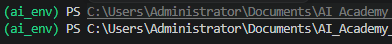

> Common mistake: do not commit `ai_env`. It is machine-specific and huge. 

> If you see it in the **Source Control** tab is because something is wrong in the `.gitignore` file. Check that the file is in the root of the project and that it contains the line `ai_env`.

### Installing libraries to the virtual environment

The [`requirements.txt`](./requirements.txt) file contains a lot of libraries that we are going to use throughout the module. To install all of them in the virtual environment we need to run the next command **in the terminal**:

In [ ]:
# DO NOT RUN THIS CELL

# Copy the content of this cell, paste it in the terminal, and run it.
pip install -r requirements.txt

### FastAPI Installation

Sometimes could happen that you need some extra library that you haven't installed initially with the `requirements.txt` (like we just did). In that case, if we have our virtual environment active, we can run the next command and it will install the libraries there:

On next, let's install FastAPI:

```bash
pip install "fastapi[standard]"
```

> What happens if the virtual env is not active?

> The Packages Installer for Python (`pip`) will install it in the default environment that is the Python installation of your machine. 

If you want to keep the requirements.txt file updated with the new library, we can run the next command:

In [ ]:
pip freeze > requirements.txt

If you are curious about what libraries are installed in the virtual environment, we can run the next command:

In [ ]:
pip list


# Hands-on — Step 2: Hello World in FastAPI

Goal: build the smallest possible FastAPI app and see it documented in Swagger.

## File layout

All the code we write from now on goes into files **next to this notebook**, in the same folder. The kernel's working directory is the folder where this notebook lives.

```text
AI Academy/
  1_fastapi_ai_lab_product.ipynb   <- you are here
  fastapi_lesson/main.py           <- the FastAPI app we are going to build now
```
## 2.1 Create the folder `fastapi_lesson`

`fastapi_lesson` is the entry point of the application. It will contain the `FastAPI` application object.

## 2.2 Create `main.py`

Create a new text file inside the previously created folder and put as name `main.py`. 
This file is the entry point of the application. It will contain the `FastAPI` application object.


In [ ]:
### DO NOT EXECUTE THIS CELL: Copy in fastapi_lesson/main.py
from fastapi import FastAPI

app = FastAPI(
    title="API Intro @ LLM Course",
    version="0.1.0",
    description="Backend example built during the LLM course",
) # This is the application object and each property documents the API.



@app.get("/health") # It is a good practice to have an endpoint to monitor if the application is alive.
def health_check():
    return {"status": "ok"} # FastAPI automatically converts dict to JSON and sets the correct content-type header.


Line-by-line:

- `from fastapi import FastAPI` imports the main class used to create an API app.
- `app = FastAPI(...)` creates the application object.
- `title`, `version`, and `description` are metadata shown in the generated docs.
- `@app.get("/health")` is a decorator. It connects a GET request at `/health` to the function below it.
- `health_check()` is the route function.
- Returning a dictionary is enough: FastAPI converts it to JSON.

## 2.2 Run and test

Run the app from the project folder (the one with `main.py`):

In [ ]:
# DO NOT EXECUTE THIS CELL: 
# 
# Copy in the terminal and run it.

fastapi dev fastapi_lesson/main.py

Open the browser:

```text
http://localhost:8000/health
```

Expected:

```json
{
  "status": "ok"
}
```

Now let's open a docs that FastAPI provides out of the box (Swagger UI):

```text
http://localhost:8000/docs
```

Notice: we wrote **zero documentation code** and yet `/docs` already shows our endpoint, its method, and its response. FastAPI generates Swagger automatically from the code. This is the same interface the LiteLLM gateway exposes.

> Checkpoint: you should now have a running FastAPI app, a `/health` endpoint, and Swagger UI open.


# Hands-on — Step 3: A conversation history API

We are going to build a small API over **conversation histories** (it could be a very basic version of a chat application like Whatsapp): a list of chats, each with messages.

Why a chat history?

- It is a good example for the classic operations that an API could do, which is known as CRUD:
    - Create
    - Read
    - Update
    - Delete
- It lets us practice the HTTP methods and status codes from the slides on a realistic domain.

What are we not including here?

- A database: we will keep the data in memory for simplicity but real applications would use a database to persist data and do the same operations.

## 3.1 What we will build

We keep the API small on purpose: the goal is to learn what an API is, not to build a full product.

| Method | Path | Purpose | Success status |
| --- | --- | --- | --- |
| GET | `/api/v1/conversations` | List all conversations | 200 |
| GET | `/api/v1/conversations/{conv_id}/messages` | List messages of a conversation | 200 |
| POST | `/api/v1/conversations/{conv_id}/messages` | Append a message | 201 |
| PATCH | `/api/v1/conversations/{conv_id}/messages/{msg_id}` | Edit an already-sent message | 200 |
| DELETE | `/api/v1/conversations/{conv_id}/messages/{msg_id}` | Delete a message | 204 |

- Some other endpoints like one for creating a conversation (`POST /api/v1/conversations`) and getting one conversation (`GET /api/v1/conversations/{conv_id}`) could be added, but to keep it short, we omit those. If you want, you can add them later as an exercise.


## 3.2 Schemas: Pydantic schemas (in `main.py`)

Pydantic is FastAPI's validation engine. Schemas are Python classes with type hints; they validate and serialize data.

## 3.3 Routes: inside `main.py`

We define the routes directly under the `FastAPI` app object. The router step comes later (layered architecture).

The `main.py` below contains everything so far: schemas, in-memory data, helpers, and the conversation routes. Read the comments inside the code — they explain each line.


In [ ]:
### Replace the code in fastapi_lesson/main.py with the next code
from enum import Enum

from fastapi import FastAPI, HTTPException, status
from pydantic import BaseModel, Field

app = FastAPI(
    title="API Intro @ LLM Course",
    version="0.1.0",
    description="Backend example built during the LLM course",
) # This is the application object and each property documents the API.

# ---------------------------------------------------------------------------
# In-memory data
# ---------------------------------------------------------------------------

# Start with one default conversation so there is something to retrieve
# from the very first moment (with one assistant message inside).
conversations = [
    {
        "id": 1,
        "title": "Welcome",
        "messages": [
            {
                "id": 1,
                "role": "assistant",
                "content": "Welcome to the AI Lab chat! Ask me anything about APIs.",
            }
        ],
    }
]
next_conversation_id = 2
next_message_id = 2

# ---------------------------------------------------------------------------
# Schemas (Pydantic models) - data validation
# ---------------------------------------------------------------------------

class MessageRole(str, Enum):
    # Limits "role" to the three roles OpenAI accepts (spoiler for next lesson).
    user = "user"
    assistant = "assistant"
    system = "system"


class MessageCreate(BaseModel):
    # Body sent when appending a message.
    # Field(...) adds constraints; invalid input gets an automatic 422.
    role: MessageRole
    content: str = Field(min_length=1, max_length=2000)


class MessageResponse(BaseModel):
    # What the API returns for a message.
    id: int
    role: MessageRole
    content: str


class ConversationResponse(BaseModel):
    # What the API returns for a conversation: it embeds the messages.
    id: int
    title: str
    messages: list[MessageResponse] = []


class MessageUpdate(BaseModel):
    # Body sent when editing an already-sent message.
    content: str = Field(min_length=1, max_length=2000)



# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _find_conversation(conv_id: int) -> dict:
    for conversation in conversations:
        if conversation["id"] == conv_id:
            return conversation

    # HTTPException: real status code instead of {"error": ...}
    raise HTTPException(
        status_code=status.HTTP_404_NOT_FOUND,
        detail="Conversation not found",
    )


def _find_message(conversation: dict, message_id: int) -> dict:
    for message in conversation["messages"]:
        if message["id"] == message_id:
            return message

    raise HTTPException(
        status_code=status.HTTP_404_NOT_FOUND,
        detail="Message not found",
    )


# ---------------------------------------------------------------------------
# Routes - conversation history API (WhatsApp-like)
# ---------------------------------------------------------------------------

@app.get("/api/v1/conversations", response_model=list[ConversationResponse])
def list_conversations():
    """List all conversations."""
    return conversations


@app.get(
    "/api/v1/conversations/{conv_id}/messages",
    response_model=list[MessageResponse],
)
def list_messages(conv_id: int):
    """List the messages of a conversation."""
    conversation = _find_conversation(conv_id)
    return conversation["messages"]


@app.post(
    "/api/v1/conversations/{conv_id}/messages",
    response_model=MessageResponse,
    status_code=status.HTTP_201_CREATED,
)
def add_message(conv_id: int, payload: MessageCreate):
    """Append a message to a conversation."""
    global next_message_id

    conversation = _find_conversation(conv_id)

    message = {
        "id": next_message_id,
        "role": payload.role,
        "content": payload.content,
    }
    conversation["messages"].append(message)
    next_message_id += 1

    return message


@app.patch(
    "/api/v1/conversations/{conv_id}/messages/{message_id}",
    response_model=MessageResponse,
)
def edit_message(conv_id: int, message_id: int, payload: MessageUpdate):
    """Edit the content of an already-sent message (WhatsApp style)."""
    conversation = _find_conversation(conv_id)
    message = _find_message(conversation, message_id)

    message["content"] = payload.content

    return message


@app.delete(
    "/api/v1/conversations/{conv_id}/messages/{message_id}",
    status_code=status.HTTP_204_NO_CONTENT,
)
def delete_message(conv_id: int, message_id: int):
    """Delete a sent message."""
    conversation = _find_conversation(conv_id)
    message = _find_message(conversation, message_id)

    conversation["messages"].remove(message)
    return None


# ---------------------------------------------------------------------------
# Health check
# ---------------------------------------------------------------------------

@app.get("/health")
def health_check():
    # Returning a dictionary is enough: FastAPI converts it to JSON.
    return {"status": "ok"}

## Step 4: Add authentication to the conversation endpoints

So far, our API is completely open: anyone can list conversations, list messages, add messages, edit them, or delete them. Real products protect their resources.

In this step we add a **didactic-only** authentication check to **every conversation endpoint**:

- The client must send an `Authorization` header.
- The value of that header must be one of a small set of allowed names hardcoded on the server (`manuel`, `ana`, `bruno`).
- If the header is missing, or its value is not in the allowed list, the API answers `401 Unauthorized`.

### The idiomatic way: dependencies (`Depends`)

Instead of repeating the check inside every function, we write it **once** in a function called `require_auth`, and each endpoint declares it with `Depends`:

```python
@app.get("/api/v1/conversations")
def list_conversations(user: str = Depends(require_auth)):
    ...
```

How it works:

- `Depends(require_auth)` tells FastAPI: *"run `require_auth()` before this endpoint, and inject its return value as `user`"*.
- FastAPI resolves `require_auth`'s own parameters (the `Authorization` header) just like an endpoint.
- If `require_auth` raises `HTTPException`, FastAPI returns the error and the endpoint logic never runs.
- The endpoint code stays clean: no duplicated `if authorization is None` checks.

> ⚠️ **Didactic note**: this is NOT how real authentication works. Real API keys and JWT tokens are created through a login or key-management process (see the slides: *Client Authentication Methods* — API Keys & Secrets, JWT/OAuth 2.0). Here the only goals are (1) to practice reading `Header` values in FastAPI, (2) to use a dependency, and (3) to be able to return `401` when the header is not present.

All the code in `main.py` should be replaced with the new version below. It is a copy of the previous one, with the authentication moved into the `require_auth` dependency and applied to every conversation method (`GET`, `POST`, `PATCH`, `DELETE`).

In [ ]:
### Replace the code in fastapi_lesson/main.py with the next code
from enum import Enum

from fastapi import Depends, FastAPI, HTTPException, status
from pydantic import BaseModel, Field

app = FastAPI(
    title="API Intro @ LLM Course",
    version="0.1.0",
    description="Backend example built during the LLM course",
) # This is the application object and each property documents the API.

# ---------------------------------------------------------------------------
# In-memory data
# ---------------------------------------------------------------------------

# Start with one default conversation so there is something to retrieve
# from the very first moment (with one assistant message inside).
conversations = [
    {
        "id": 1,
        "title": "Welcome",
        "messages": [
            {
                "id": 1,
                "role": "assistant",
                "content": "Welcome to the AI Lab chat! Ask me anything about APIs.",
            }
        ],
    }
]
next_conversation_id = 2
next_message_id = 2

# ---------------------------------------------------------------------------
# Schemas (Pydantic models) - data validation
# ---------------------------------------------------------------------------

class MessageRole(str, Enum):
    # Limits "role" to the three roles OpenAI accepts (spoiler for next lesson).
    user = "user"
    assistant = "assistant"
    system = "system"


class MessageCreate(BaseModel):
    # Body sent when appending a message.
    # Field(...) adds constraints; invalid input gets an automatic 422.
    role: MessageRole
    content: str = Field(min_length=1, max_length=2000)


class MessageResponse(BaseModel):
    # What the API returns for a message.
    id: int
    role: MessageRole
    content: str


class ConversationResponse(BaseModel):
    # What the API returns for a conversation: it embeds the messages.
    id: int
    title: str
    messages: list[MessageResponse] = []


class MessageUpdate(BaseModel):
    # Body sent when editing an already-sent message.
    content: str = Field(min_length=1, max_length=2000)


# ---------------------------------------------------------------------------
# Authentication (DIDACTIC ONLY - not real security)
# ---------------------------------------------------------------------------

# Allowed names, received through the Authorization header.
AUTHORIZED_USERS = ["manuel", "ana", "bruno"]


def require_auth(authorization: str | None = Header(default=None)) -> str:
    """
    Dependency that protects an endpoint.

    How Depends works:
    - An endpoint that declares `user: str = Depends(require_auth)` tells
      FastAPI: "before running my code, run require_auth() for me".
    - FastAPI sees the parameters of require_auth (here: `authorization`),
      resolves them exactly like it would for an endpoint (here: it reads
      the Authorization header), and calls require_auth(**those values).
    - If require_auth raises an HTTPException, FastAPI returns that error
      immediately and the endpoint code NEVER runs.
    - If require_auth returns a value (here: the verified user), FastAPI
      injects it into the endpoint as the `user` parameter.

    Because every conversation endpoint declares this same dependency, the
    check is not repeated inside each function: one dependency, many routes.
    """

    # If the header is missing -> 401 Unauthorized.
    if authorization is None:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail="Missing Authorization header",
        )

    if authorization not in AUTHORIZED_USERS:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED, ### FIXME: What's wrong here?
            detail="Invalid credentials",
        )

    # Authorized: return the verified user so the endpoint can use it if needed.
    return authorization


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _find_conversation(conv_id: int) -> dict:
    for conversation in conversations:
        if conversation["id"] == conv_id:
            return conversation

    # HTTPException: real status code instead of {"error": ...}
    raise HTTPException(
        status_code=status.HTTP_404_NOT_FOUND,
        detail="Conversation not found",
    )


def _find_message(conversation: dict, message_id: int) -> dict:
    for message in conversation["messages"]:
        if message["id"] == message_id:
            return message

    raise HTTPException(
        status_code=status.HTTP_404_NOT_FOUND,
        detail="Message not found",
    )


# ---------------------------------------------------------------------------
# Routes - conversation history API (WhatsApp-like), all protected
# ---------------------------------------------------------------------------

@app.get("/api/v1/conversations", response_model=list[ConversationResponse])
def list_conversations(user: str = Depends(require_auth)):
    """List all conversations."""
    return conversations


@app.get(
    "/api/v1/conversations/{conv_id}/messages",
    response_model=list[MessageResponse],
)
def list_messages(conv_id: int, user: str = Depends(require_auth)):
    """List the messages of a conversation."""
    conversation = _find_conversation(conv_id)
    return conversation["messages"]


@app.post(
    "/api/v1/conversations/{conv_id}/messages",
    response_model=MessageResponse,
    status_code=status.HTTP_201_CREATED,
)
def add_message(conv_id: int, payload: MessageCreate, user: str = Depends(require_auth)):
    """Append a message to a conversation."""
    global next_message_id

    conversation = _find_conversation(conv_id)

    message = {
        "id": next_message_id,
        "role": payload.role,
        "content": payload.content,
    }
    conversation["messages"].append(message)
    next_message_id += 1

    return message


@app.patch(
    "/api/v1/conversations/{conv_id}/messages/{message_id}",
    response_model=MessageResponse,
)
def edit_message(conv_id: int, message_id: int, payload: MessageUpdate, user: str = Depends(require_auth)):
    """Edit the content of an already-sent message (WhatsApp style)."""
    conversation = _find_conversation(conv_id)
    message = _find_message(conversation, message_id)

    message["content"] = payload.content

    return message


@app.delete(
    "/api/v1/conversations/{conv_id}/messages/{message_id}",
    status_code=status.HTTP_204_NO_CONTENT,
)
def delete_message(conv_id: int, message_id: int, user: str = Depends(require_auth)):
    """Delete a sent message."""
    conversation = _find_conversation(conv_id)
    message = _find_message(conversation, message_id)

    conversation["messages"].remove(message)
    return None


# ---------------------------------------------------------------------------
# Health check (NOT protected: it is a monitoring endpoint)
# ---------------------------------------------------------------------------

@app.get("/health")
def health_check():
    # Returning a dictionary is enough: FastAPI converts it to JSON.
    return {"status": "ok"}

# Step 5: Layered Architecture

The slides close with a key principle: **prevent the chaos of having all the backend implementation in a single file**.

Until now, `fastapi_lesson/main.py` has everything: schemas, in-memory data, auth, helpers, and routes. That is fine while learning, but a real project organizes code into **layers** so each file has a single responsibility.

## The three backend layers (from the slides)

| Layer | Responsibility |
| --- | --- |
| **Routers / Controllers** | Manages network endpoints and HTTP routing. Receives incoming requests, handles path operations, enforces CORS, and forwards payloads down to the service layer. |
| **Services** | The core business logic. Processes business rules, performs calculations, manages application state, and orchestrates external requests. |
| **Schemas** | Defines data models and validation structures using Pydantic. Guarantees data integrity by serializing outgoing responses and strictly parsing incoming HTTP payloads. |

> Note: the slides mention that other frameworks use different names — Controllers can take Routers logic, and Models can act like Schemas. We use the slide names: **routers**, **services**, **schemas**.

## What goes in each layer (for our app)

Our `main.py` currently has these pieces:

- **Schemas** → `MessageRole`, `MessageCreate`, `MessageResponse`, `ConversationResponse`, `MessageUpdate` → move to `app/schemas/`
- **Routes** → `list_conversations`, `list_messages`, `add_message`, `edit_message`, `delete_message` → move to `app/routes/conversations.py`
- **Auth** → `AUTHORIZED_USERS`, `require_auth` → move to `app/routes/security.py` (it protects routes, so it lives in the routers layer)
- **Helpers / business logic** → `_find_conversation`, `_find_message` → move to `app/services/conversations.py` (services layer)
- **App assembly** → `app = FastAPI(...)` + `/health` → stays in `main.py`

## Folder structure to create

```text
fastapi_lesson/
  main.py                      <- FastAPI app + router wiring (final version at the end)
  app/
    __init__.py                <- makes `app` a Python package
    routes/
      __init__.py
      main.py                  <- exposes all routers
      conversations.py         <- the conversation routes
      security.py              <- AUTHORIZED_USERS + require_auth
    services/
      __init__.py
      conversations.py         <- _find_conversation, _find_message
    schemas/
      __init__.py
      conversations.py         <- the Pydantic models
```

Follow the steps below: **create the files, copy the code that belongs in each one, and finally replace `main.py`** with the final version that connects everything.


In [ ]:
# Create the package structure (run once)
from pathlib import Path

for folder in [
    "fastapi_lesson/app",
    "fastapi_lesson/app/routes",
    "fastapi_lesson/app/services",
    "fastapi_lesson/app/schemas",
]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Folders created.")


### Create `fastapi_lesson/app/__init__.py`

A package marker (can be empty). The `__init__.py` files tell Python that a folder is a package.


In [ ]:
%%writefile fastapi_lesson/app/__init__.py
# Package marker.


### Create the schemas layer

```text
fastapi_lesson/app/schemas/__init__.py
fastapi_lesson/app/schemas/conversations.py
```

Copy the Pydantic models from `main.py`: `MessageRole`, `MessageCreate`, `MessageResponse`, `ConversationResponse`, `MessageUpdate`. They only need `from enum import Enum` and `from pydantic import BaseModel, Field`.


In [ ]:
%%writefile fastapi_lesson/app/schemas/__init__.py
# Package marker.


In [ ]:
%%writefile fastapi_lesson/app/schemas/conversations.py
# TODO: copy the Pydantic models from main.py
# MessageRole, MessageCreate, MessageResponse, ConversationResponse, MessageUpdate


### Create the services layer

```text
fastapi_lesson/app/services/__init__.py
fastapi_lesson/app/services/conversations.py
```

Move the **helpers** (`_find_conversation`, `_find_message`) here. That is the business logic the routes will call. They need `from fastapi import HTTPException, status`.


In [ ]:
%%writefile fastapi_lesson/app/services/__init__.py
# Package marker.


In [ ]:
%%writefile fastapi_lesson/app/services/conversations.py
# TODO: move the helpers here
# _find_conversation, _find_message (they raise HTTPException 404)
# They need: from fastapi import HTTPException, status


### Create the routers layer

```text
fastapi_lesson/app/routes/__init__.py
fastapi_lesson/app/routes/security.py
fastapi_lesson/app/routes/conversations.py
fastapi_lesson/app/routes/main.py
```

- `security.py`: move `AUTHORIZED_USERS` and `require_auth`.
- `conversations.py`: move the routes. Change `@app` to `@router` by creating an `APIRouter`, and import the services + schemas.
- `main.py`: expose all routers as a list (so the root `main.py` can include them).


In [ ]:
%%writefile fastapi_lesson/app/routes/__init__.py
# Package marker.


In [ ]:
%%writefile fastapi_lesson/app/routes/security.py
# TODO: move AUTHORIZED_USERS and require_auth here
# Needs: from fastapi import Depends, HTTPException, status, Header


In [ ]:
%%writefile fastapi_lesson/app/routes/conversations.py
# TODO: move the conversation routes here
# - create an APIRouter: router = APIRouter(prefix="/api/v1/conversations", tags=["Conversations"])
# - change @app.get -> @router.get, @app.post -> @router.post, etc.
# - import the schemas from app.schemas.conversations
# - import the services from app.services.conversations
# - each route keeps: user: str = Depends(require_auth) (import from app.routes.security)


In [ ]:
%%writefile fastapi_lesson/app/routes/main.py
# TODO: import all routers and expose them as a list
# Example:
# from app.routes.conversations import router as conversations_router
# all_routers = [conversations_router]


### Final `main.py` (connects the layers)

Once the files above are created and filled, replace `fastapi_lesson/main.py` with this version. It only creates the app and connects the routers — the same behavior as before, but organized in layers:


In [ ]:
%%writefile fastapi_lesson/main.py
from fastapi import FastAPI

from app.routes.main import all_routers

app = FastAPI(
    title="AI Lab API",
    version="0.1.0",
    description="Backend product built during the AI Lab FastAPI course",
)


@app.get("/health")
def health_check():
    return {"status": "ok"}


for router in all_routers:
    app.include_router(router)


### Test the layered app

Run:

```bash
fastapi dev fastapi_lesson/main.py
```

Open `/docs` and repeat the tests from Step 4:

- `GET /api/v1/conversations` → still requires the `Authorization` header → `200` with the Welcome conversation (or `401` if missing).
- `POST /api/v1/conversations/{conv_id}/messages` → still works with auth.

> Checkpoint: the app behaves exactly as before, but now the code is organized into layers. If something fails, check that each import points to the right module and that no route forgot its `Depends(require_auth)`.